In [1]:
#source TFAvenv/bin/activate (launching and exiting the virtual environment containing the required modules, stored in the working directory)
#TFAvenv/bin/python your_script.py - for running a script in the virtual environment
#source deactivate

#import all the libraries needed
from import_dep import *
import importlib

# import my functions stored in the file 'functions' which can then be called with functions.function_name()
from SMU import SMU
import SMU_functions
importlib.reload(SMU_functions)  # Force reload to get updated function signatures
from SMU_functions import (plot_IV_3T, plot_resistance_3T, extract_fet_params,
                           extract_hysteresis, plot_hysteresis_evolution,
                           fit_hysteresis_model, plot_charge_correlation,
                           smooth_smu_data)

# import custom plot style and colorbar functions
import plot_style
importlib.reload(plot_style)  # Force reload to get updated markersize parameter
from plot_style import set_plot_style

# Define the path to the root directory containing the 3T FET data
root_SMU_DR009 = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/DR009'
root_SMU_EM025 = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/EM025'
root_SMU_EM026 = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/EM026'

root_SMU_SM04 = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/SM04/Data'
output_SMU_SM04 = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/SM04/Output'

root_SMU_SM06 = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/SM06/Data'
output_SMU_SM06 = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/SM06/Output'


#Define the output directory
output_SMU = root_SMU_EM026 + '/Output'  # Output directory for DR009 data; adjust if needed

### Plotting and Output Variables 
export_data = False # set to True to export the data to a powerpoint presentation and as svg files and export to path_out
fig_format = 'svg' # format of the figure to be saved

powerpoint_string = 'ALD_FeFET' # string to be added to the powerpoint file name

plot_transparency = True # set to True to make the data plots transparent

# Custom plot style settings with small markersize
fig_size = set_plot_style(export_data=export_data, use_tex=True, markersize=0.1)


In [2]:
# Load 3-terminal FET data
print("Loading 3T FET data...")

smu_DR009 = SMU(root_SMU_EM026)
smu_SM04 = SMU(root_SMU_SM04)
smu_SM06 = SMU(root_SMU_SM06)


# Display available IV3T runs
print(f"\nAvailable IV3T run numbers in DR009: {smu_DR009.iv3T_run_nums}")
print(f"Number of IV3T files in DR009: {len(smu_DR009.iv3T_data)}")
print(f"\nAvailable IV3T run numbers in SM04: {smu_SM04.iv3T_run_nums}")
print(f"Number of IV3T files in SM04: {len(smu_SM04.iv3T_data)}")
print(f"\nAvailable IV3T run numbers in SM06 : {smu_SM06.iv3T_run_nums}")
print(f"Number of IV3T files in SM06: {len(smu_SM06.iv3T_data)}")

# Show sample data structure
if smu_DR009.iv3T_data:
    print(f"\nSample IV3T data columns: {smu_DR009.iv3T_data[0].columns.tolist()}")
    print(smu_DR009.iv3T_data[0].head())

Loading 3T FET data...
Found 54 Excel files
Error processing IV3T file Id_vs_Vg_6FET_6#1 Run52 04-14-2026.xlsx: single positional indexer is out-of-bounds
Loaded 0 CV, 0 IV, 53 IV3T files
Found 103 Excel files
Loaded 0 CV, 1 IV, 102 IV3T files
Found 35 Excel files
Loaded 0 CV, 2 IV, 33 IV3T files

Available IV3T run numbers in DR009: [1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 3, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 4, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 5, 50, 51, 53, 54, 6, 7, 8, 9]
Number of IV3T files in DR009: 53

Available IV3T run numbers in SM04: [1, 10, 100, 101, 102, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 3, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 4, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 5, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 6, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 7, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 8, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 9, 90, 91, 92, 93, 94, 95, 96

## Optional: Smooth raw data

Apply a smoothing filter to the drain current **before** any analysis. This modifies the SMU data in place — all subsequent plots and extractions will use the smoothed data. Re-run the import cell above to restore the original data.

| Method | Best for | Notes |
|--------|----------|-------|
| `'savgol'` | General use | Preserves peak shapes and derivatives; set `polyorder` (default 2) |
| `'median'` | Spike removal | Robust to outliers; good for noisy contacts |
| `'boxcar'` | Heavy averaging | Simple moving average; broadens features |
| `'none'` | No smoothing | Pass-through (default) |

In [3]:
### Smoothing settings — change these and re-run this cell ###
smooth_method = 'savgol'   # 'savgol', 'median', 'boxcar', or 'none'
smooth_window = 7      # window size in points (must be odd for savgol/median)
smooth_polyorder = 2    # polynomial order (savgol only)
smooth_columns = ('D_I_A',)  # which columns to smooth

# Apply smoothing (re-import above to undo)
smooth_smu_data(smu_DR009, columns=smooth_columns,
                method=smooth_method, window=smooth_window,
                polyorder=smooth_polyorder)

if smooth_method != 'none':
    print(f"Smoothing applied: {smooth_method}, window={smooth_window}")
else:
    print("No smoothing applied (method='none')")

Smoothing applied: savgol, window=7


# FET Transfer Characteristics ($I_D$ vs $V_G$)

The transfer characteristic is the defining measurement of a field-effect transistor: we sweep the gate voltage $V_G$ at a fixed drain voltage $V_D$ and measure the drain current $I_D$. This reveals how effectively the gate modulates the channel conductance.

**Key figures of merit extracted from the transfer curve:**

| Parameter | Symbol | How to extract | Typical units |
|-----------|--------|---------------|---------------|
| Threshold voltage | $V_{\text{th}}$ | Linear extrapolation from max-$g_m$ point | V |
| Subthreshold swing | $SS$ | $dV_G / d(\log_{10}|I_D|)$ in the steepest subthreshold region | mV/dec |
| On/off ratio | $I_{\text{on}}/I_{\text{off}}$ | $\max|I_D| \,/\, \min|I_D|$ | dimensionless |
| Peak transconductance | $g_{m,\text{max}}$ | $\max(dI_D/dV_G)$ | S |
| Field-effect mobility | $\mu_{FE}$ | $g_{m,\text{max}} \cdot L \,/\, (W \cdot C_{\text{ox}} \cdot V_D)$ | cm$^2$/Vs |

## Linear Transfer Curve

**Plot:** $I_D$ vs $V_G$

**What to look for:**
- A clear transition from off-state (low $I_D$) to on-state (high $I_D$) as $V_G$ increases past threshold.
- The slope in the linear region above threshold is proportional to the transconductance $g_m$.
- Hysteresis between forward and reverse sweeps indicates charge trapping at the interface or in the gate dielectric.

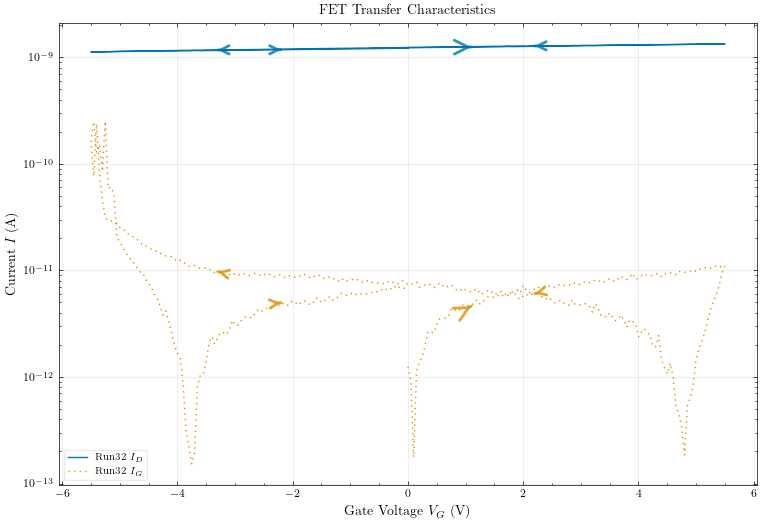

In [97]:
## Linear Transfer Curve — Drain Current

selected_runs =  [51, 53, 54]#[42, 43, 44, 45, 46, 47, 48, 49] #[39, 40, 41, ]#smu_DR009.iv3T_run_nums  # Plot all runs, or select specific ones e.g. [34, 35]
#selected_runs = [58,70,71...] # SM04: 50 onwards is vac anneal - 70 is O anneal start 

#[60,61,62,63,64,65] 58

fig_transfer = plot_IV_3T([smu_SM06], 
                          run_nums=[32], #84, 85, 86, 96,97,98,99
                          x_terminal='gate',
                          terminal_display=['drain', 'gate'],  # 'gate', 'drain', or 'source'
                          plot_mode='log',
                          plot_arrows=True,
                          #line_width=0.6,
                          #markersize=0.9,
                          fig_format=fig_format,
                          fig_name = 'test',
                          export_data=False,
                          output_SMU=output_SMU_SM06,
                          plot_transparency=plot_transparency)

## Log-Scale Transfer Curve

**Plot:** $|I_D|$ vs $V_G$ (log y-axis)

The log-scale transfer curve is essential for evaluating:
- **On/off current ratio**: the vertical span between maximum and minimum $|I_D|$ on the log axis.
- **Subthreshold swing** $SS$: the inverse slope $dV_G / d(\log_{10}|I_D|)$ in the subthreshold region. The theoretical limit at room temperature is $\approx 60$ mV/dec.
- **Off-state leakage**: the minimum achievable $|I_D|$ — dominated by gate leakage or junction leakage.

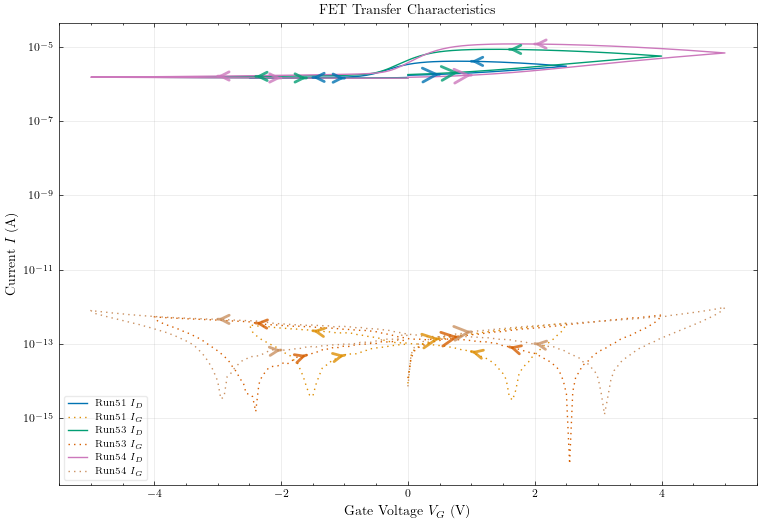

In [5]:
## Log-Scale Transfer Curve — Drain Current

fig_log = plot_IV_3T([smu_DR009], run_nums=selected_runs,
                     x_terminal='gate',
                     terminal_display=['drain', 'gate'],
                     plot_mode='log',
                     plot_arrows=True,
                     fig_format=fig_format,
                     export_data=export_data, output_SMU=output_SMU,
                     plot_transparency=plot_transparency)

## Gate Leakage Monitoring

For ECRAM-style devices and sequential breakdown studies, gate leakage $I_G$ is a critical diagnostic. Plotting $I_D$ and $I_G$ together on a log scale reveals:

- **Gate dielectric integrity**: $I_G \ll I_D$ indicates a healthy gate stack.
- **Progressive breakdown**: $I_G$ increasing across successive sweeps signals degradation of the gate oxide.
- **Leakage-dominated off-state**: when $I_G \gtrsim I_D$ in the off-state, the measured off-current is actually gate leakage, not channel leakage.

In [6]:
## Log-Scale Transfer — Drain + Gate Current (leakage monitoring)

fig_leak = plot_IV_3T([smu_DR009], run_nums=selected_runs,
                      x_terminal='gate',
                      terminal_display=['drain', 'gate'],  # overlay gate leakage
                      plot_mode='log',
                      plot_arrows=True,
                      fig_format=fig_format,
                      export_data=export_data, output_SMU=output_SMU,
                      plot_transparency=plot_transparency)

KeyboardInterrupt: 

## Transconductance

The transconductance $g_m = dI_D / dV_G$ quantifies how efficiently the gate voltage modulates the drain current — it is the small-signal gain of the transistor.

$$g_m = \frac{dI_D}{dV_G}$$

**What to look for:**
- **Peak $g_m$**: occurs near threshold and determines the maximum intrinsic voltage gain.
- **Peak position**: the gate voltage at peak $g_m$ is used for threshold voltage extraction via linear extrapolation.
- **Shape**: a broad, flat peak indicates good linearity; a narrow spike suggests interface traps or mobility degradation.

Use `smooth_window` (odd integer, e.g. 11) if the derivative is noisy.

/Users/horatiocox/Desktop/Thin_Film_Analysis/TFAvenv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1290: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/Users/horatiocox/Desktop/Thin_Film_Analysis/TFAvenv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1292: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/horatiocox/Desktop/Thin_Film_Analysis/TFAvenv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1298: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]


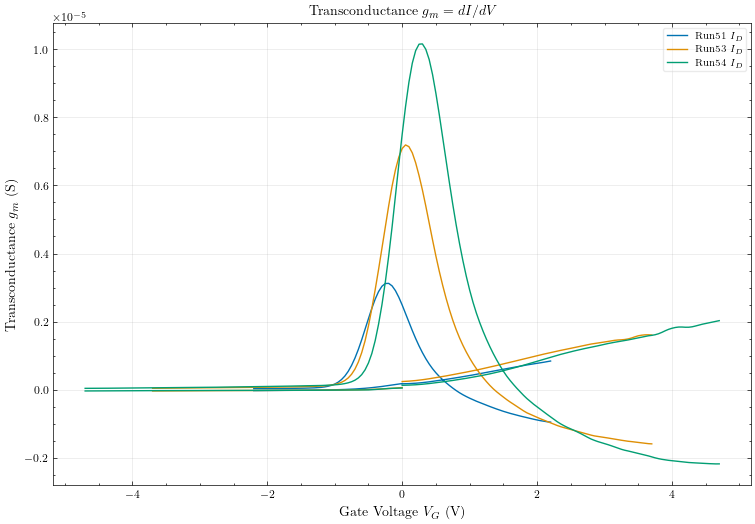

In [ ]:
## Transconductance gm = dId/dVg

fig_gm = plot_IV_3T([smu_DR009], run_nums=selected_runs,
                    x_terminal='gate',
                    terminal_display=['drain'],
                    plot_mode='transconductance',
                    smooth_window=11,  # Savitzky-Golay smoothing; set to None for raw derivative
                    fig_format=fig_format,
                    export_data=export_data, output_SMU=output_SMU,
                    plot_transparency=plot_transparency)

## $\sqrt{|I_D|}$ vs $V_G$ — Saturation Mobility Extraction

In the saturation regime ($V_D > V_G - V_{\text{th}}$), the drain current follows:

$$I_D = \frac{\mu_{\text{sat}} C_{\text{ox}} W}{2L} (V_G - V_{\text{th}})^2$$

Taking the square root gives a linear relationship:

$$\sqrt{|I_D|} = \sqrt{\frac{\mu_{\text{sat}} C_{\text{ox}} W}{2L}} \;(V_G - V_{\text{th}})$$

**What to look for:**
- A **straight line** in the on-state confirms the device is in saturation.
- The **slope** gives $\sqrt{\mu_{\text{sat}} C_{\text{ox}} W / (2L)}$, yielding the saturation mobility if $C_{\text{ox}}$, $W$, $L$ are known.
- The **x-intercept** of the linear extrapolation gives $V_{\text{th}}$.

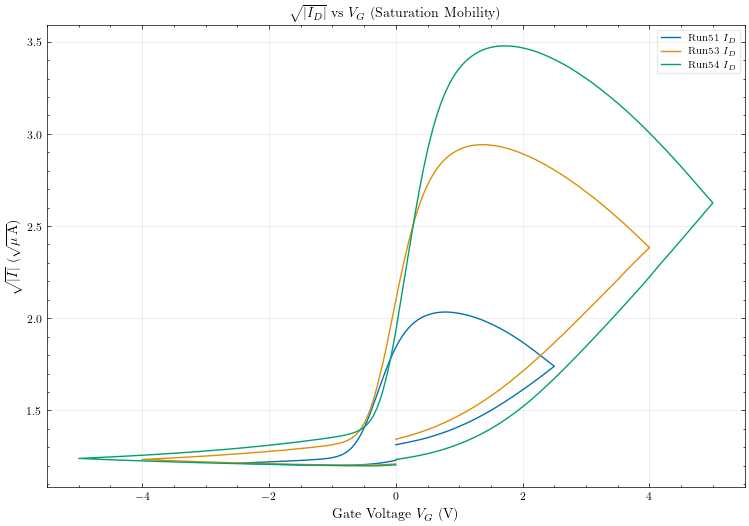

In [ ]:
## sqrt(Id) vs Vg — saturation mobility extraction

fig_sqrt = plot_IV_3T([smu_DR009], run_nums=selected_runs,
                      x_terminal='gate',
                      terminal_display=['drain'],
                      plot_mode='sqrt_Id',
                      fig_format=fig_format,
                      export_data=export_data, output_SMU=output_SMU,
                      plot_transparency=plot_transparency)

## Channel Resistance

The channel resistance $R_{\text{ch}} = V_D / I_D$ as a function of gate voltage shows how effectively the gate modulates the channel conductance. In the on-state $R_{\text{ch}}$ reaches its minimum (channel fully open), while in the off-state resistance diverges.

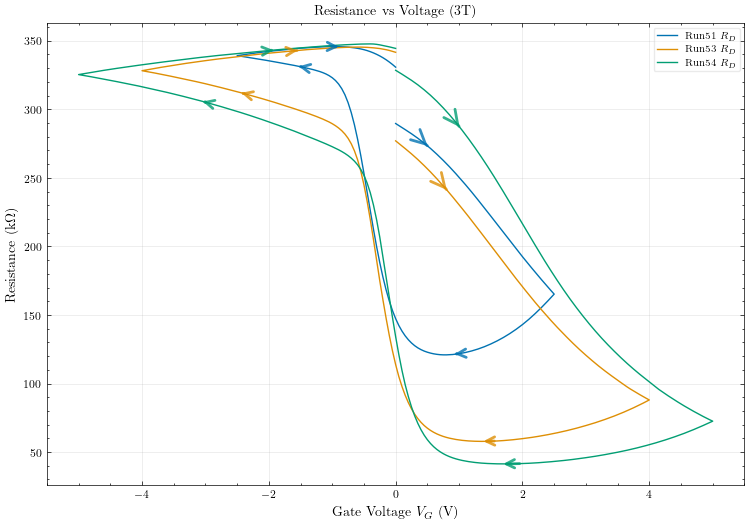

In [ ]:
## Channel Resistance vs Gate Voltage

fig_R = plot_resistance_3T([smu_DR009], run_nums=selected_runs,
                           x_terminal='gate',
                           terminal_display=['drain'],
                           log_plot=False,
                           plot_arrows=True,
                           fig_format=fig_format,
                           export_data=export_data, output_SMU=output_SMU,
                           plot_transparency=plot_transparency,
                           )

## FET Parameter Extraction

Automatically extract key transistor figures-of-merit from each transfer sweep. Device geometry parameters (`Vd`, `Cox`, `W`, `L`) are optional — if omitted, only geometry-independent parameters are extracted.

In [ ]:
## Extract FET Parameters

# Optional: provide device geometry for mobility extraction
# Vd  = 0.1       # Drain voltage during transfer sweep (V)
# Cox = 3.9e-4     # Gate capacitance per unit area (F/m^2) — e.g. 100 nm SiO2
# W   = 100e-6     # Channel width (m)
# L   = 10e-6      # Channel length (m)

params = extract_fet_params([smu_DR009], run_nums=selected_runs)

# Display results
for p in params:
    print(f"\n=== {p['run_label']} ===")
    print(f"  Threshold voltage   V_th  = {p['V_th']:.3f} V")
    print(f"  Subthreshold swing  SS    = {p['SS_mV_dec']:.1f} mV/dec")
    print(f"  On/Off ratio              = {p['on_off_ratio']:.2e}")
    print(f"  Peak transconductance gm  = {p['gm_max_S']:.3e} S")
    if 'mu_FE_cm2_Vs' in p:
        print(f"  Field-effect mobility     = {p['mu_FE_cm2_Vs']:.2f} cm^2/Vs")

# Convert to DataFrame for easy comparison
df_params = pd.DataFrame(params)
df_params


=== Run51 ===
  Threshold voltage   V_th  = -0.644 V
  Subthreshold swing  SS    = 2899.2 mV/dec
  On/Off ratio              = 2.08e+00
  Peak transconductance gm  = 1.770e-06 S

=== Run53 ===
  Threshold voltage   V_th  = -0.374 V
  Subthreshold swing  SS    = 1672.2 mV/dec
  On/Off ratio              = 3.73e+00
  Peak transconductance gm  = 4.642e-06 S

=== Run54 ===
  Threshold voltage   V_th  = -0.210 V
  Subthreshold swing  SS    = 1491.9 mV/dec
  On/Off ratio              = 4.68e+00
  Peak transconductance gm  = 5.762e-06 S


,run_label,V_th,SS_mV_dec,on_off_ratio,gm_max_S
0,Run51,-0.644465,2899.239770,2.080346,0.000002
1,Run53,-0.373667,1672.190088,3.729598,0.000005
2,Run54,-0.209601,1491.940886,4.681098,0.000006


# Gate Dielectric Conduction Mechanism Analysis

The same conduction-mechanism analysis modes available for 2-terminal devices can be applied to the gate current $I_G$ vs $V_G$ to identify the dominant leakage mechanism through the gate dielectric. This is particularly important for understanding ECRAM-style degradation.

Select `terminal_display=['gate']` and the x-axis voltage of interest.

## SCLC Analysis (Gate Leakage)

**Plot:** $\log_{10}|I_G|$ vs $\log_{10}|V_G|$

Same interpretation as 2T: slope $\alpha \approx 1$ (Ohmic), $\alpha \approx 2$ (Child's law SCLC), $\alpha \gg 2$ (TFL).

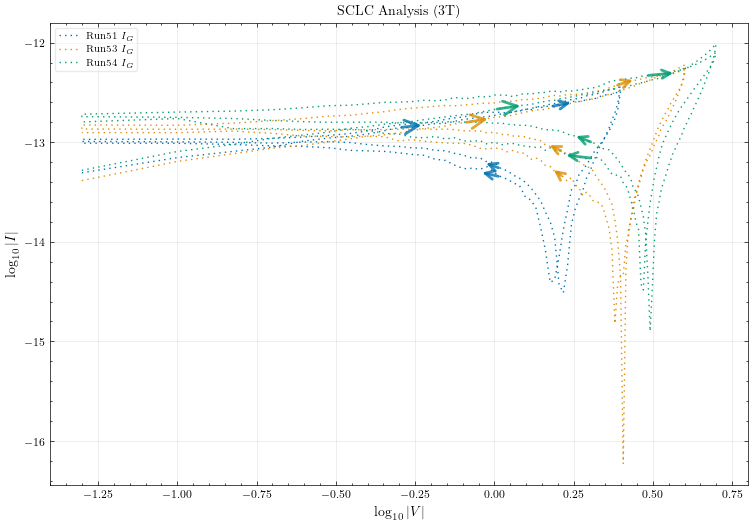

In [ ]:
## SCLC Analysis — Gate Leakage

fig_sclc = plot_IV_3T([smu_DR009], run_nums=selected_runs,
                      x_terminal='gate',
                      terminal_display=['gate'],
                      plot_mode='SCLC',
                      plot_arrows=True,
                      fig_format=fig_format,
                      export_data=export_data, output_SMU=output_SMU,
                      plot_transparency=plot_transparency)

## Schottky Emission Analysis (Gate Leakage)

**Plot:** $\ln|I_G|$ vs $\sqrt{|V_G|}$

A straight line indicates thermionic emission over the metal–oxide interface barrier.

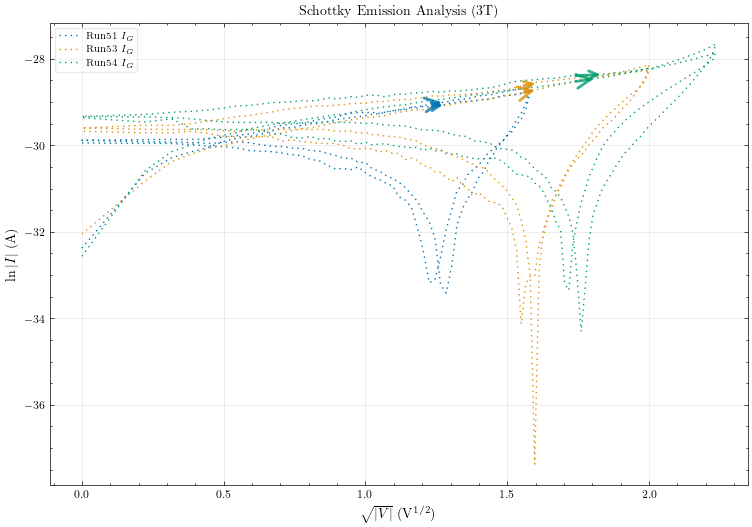

In [ ]:
## Schottky Emission — Gate Leakage

fig_sch = plot_IV_3T([smu_DR009], run_nums=selected_runs,
                     x_terminal='gate',
                     terminal_display=['gate'],
                     plot_mode='schottky',
                     plot_arrows=True,
                     fig_format=fig_format,
                     export_data=export_data, output_SMU=output_SMU,
                     plot_transparency=plot_transparency)

## Poole–Frenkel Analysis (Gate Leakage)

**Plot:** $\ln(|I_G|/|V_G|)$ vs $\sqrt{|V_G|}$

A straight line indicates bulk-limited Poole–Frenkel emission through the gate oxide. The PF slope is $2\times$ the Schottky slope — this distinguishes bulk (PF) from interface (Schottky) conduction.

In [ ]:
## Poole-Frenkel — Gate Leakage

fig_pf = plot_IV_3T([smu_DR009], run_nums=selected_runs,
                    x_terminal='gate',
                    terminal_display=['gate'],
                    plot_mode='PF',
                    plot_arrows=True,
                    fig_format=fig_format,
                    export_data=export_data, output_SMU=output_SMU,
                    plot_transparency=plot_transparency)

KeyboardInterrupt: 

## Fowler–Nordheim / Trap-Assisted Tunnelling (Gate Leakage)

**Plot:** $\ln(|I_G|/V_G^2)$ vs $1/|V_G|$

A straight line with negative slope indicates tunnelling through the gate oxide. FN dominates at high fields; TAT (via oxygen vacancies) at moderate fields with a weaker temperature dependence.

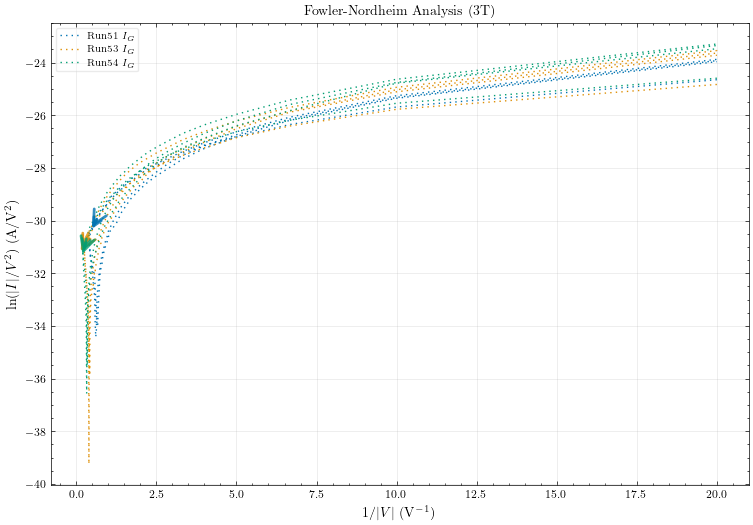

In [ ]:
## Fowler-Nordheim — Gate Leakage

fig_fn = plot_IV_3T([smu_DR009], run_nums=selected_runs,
                    x_terminal='gate',
                    terminal_display=['gate'],
                    plot_mode='FN',
                    plot_arrows=True,
                    fig_format=fig_format,
                    export_data=export_data, output_SMU=output_SMU,
                    plot_transparency=plot_transparency)

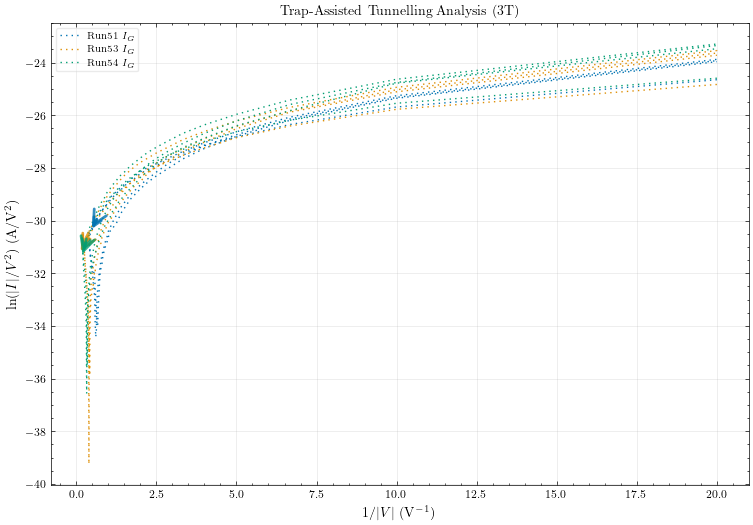

In [ ]:
## Trap-Assisted Tunnelling — Gate Leakage

fig_tat = plot_IV_3T([smu_DR009], run_nums=selected_runs,
                     x_terminal='gate',
                     terminal_display=['gate'],
                     plot_mode='TAT',
                     plot_arrows=True,
                     fig_format=fig_format,
                     export_data=export_data, output_SMU=output_SMU,
                     plot_transparency=plot_transparency)

# Hysteresis Mechanism Analysis

FET transfer curves commonly exhibit two types of hysteresis:

- **Intra-cycle**: forward vs backward sweep within a single run, quantified by $\Delta V_{\text{th}} = V_{\text{th}}^{\text{bwd}} - V_{\text{th}}^{\text{fwd}}$
- **Inter-cycle**: progressive $V_{\text{th}}$ drift across successive runs

The sign, magnitude, and evolution pattern of the hysteresis fingerprints the dominant mechanism:

| Mechanism | Hysteresis direction | $V_{\text{th}}$ drift pattern | SS evolution | $\Delta V_{\text{th}}$ vs $Q_G$ |
|-----------|---------------------|------------------------------|-------------|-------------------------------|
| **Interface charge trapping** | Clockwise (electrons) / CCW (holes) | Saturating (stretched exponential, $\beta < 1$) | SS degrades (trap states broaden subthreshold) | Weak correlation |
| **Bulk oxide trapping** | Clockwise or CCW | Saturating (stretched exp.) | SS stable (traps far from interface) | Weak correlation |
| **Mobile ion / O-vacancy drift** | Counter-clockwise (typical) | Power-law $\sim n^{0.5}$ (diffusion) or linear (drift) | SS stable | Strong ($R^2 \to 1$) |
| **Ferroelectric polarisation** | Counter-clockwise | Stable (no drift) | SS stable | No correlation |

The analysis below extracts these diagnostics from your data to distinguish the mechanism.

## Step 1: Extract Hysteresis Parameters

Split each transfer curve at the gate-voltage turning point into forward and backward half-sweeps. Extract $V_{\text{th}}$, SS, $g_m$, and on/off ratio independently for each direction. Also compute the cumulative gate charge $Q_G = \int |I_G| \, d|V_G|$ per sweep as a proxy for electrochemical activity.

Use **all available runs** here to capture the full inter-cycle evolution.

## Diagnostic: Debug $V_{\text{th}}$ Extraction

**Device type:** Depletion-mode HEMT / 2DEG — the channel conducts at $V_G = 0$ and is depleted (turned off) by applying a negative gate voltage. The threshold voltage $V_{\text{th}}$ is negative and represents the pinch-off point where the gate-modulated channel current extrapolates to zero.

**Method — baseline-corrected max-slope linear extrapolation:**

1. **Leakage baseline:** Average $I_D$ over the most-negative-$V_G$ points (the depleted end). This is the residual leakage that cannot be gated away.
2. **Subtract baseline:** $\Delta I_D = I_D - I_{\text{leakage}}$, isolating the gate-controlled channel current.
3. **Peak-$g_m$ window:** Select all points where $|g_m| \geq 50\%$ of $|g_m|_{\text{peak}}$.
4. **Linear fit:** Fit $\Delta I_D = a \cdot V_G + b$ through the window.
5. **Threshold voltage:** $V_{\text{th}} = -b/a$ — the gate voltage where the fitted line crosses $\Delta I_D = 0$ (channel fully depleted).

Panel **(a)** shows $\Delta I_D$ with the fitted tangent line and $V_{\text{th}}$ intercept. Panel **(b)** shows $g_m$ with the fitting window shaded. Panel **(c)** shows raw $I_D$ with the leakage baseline and $V_{\text{th}}$ marked.

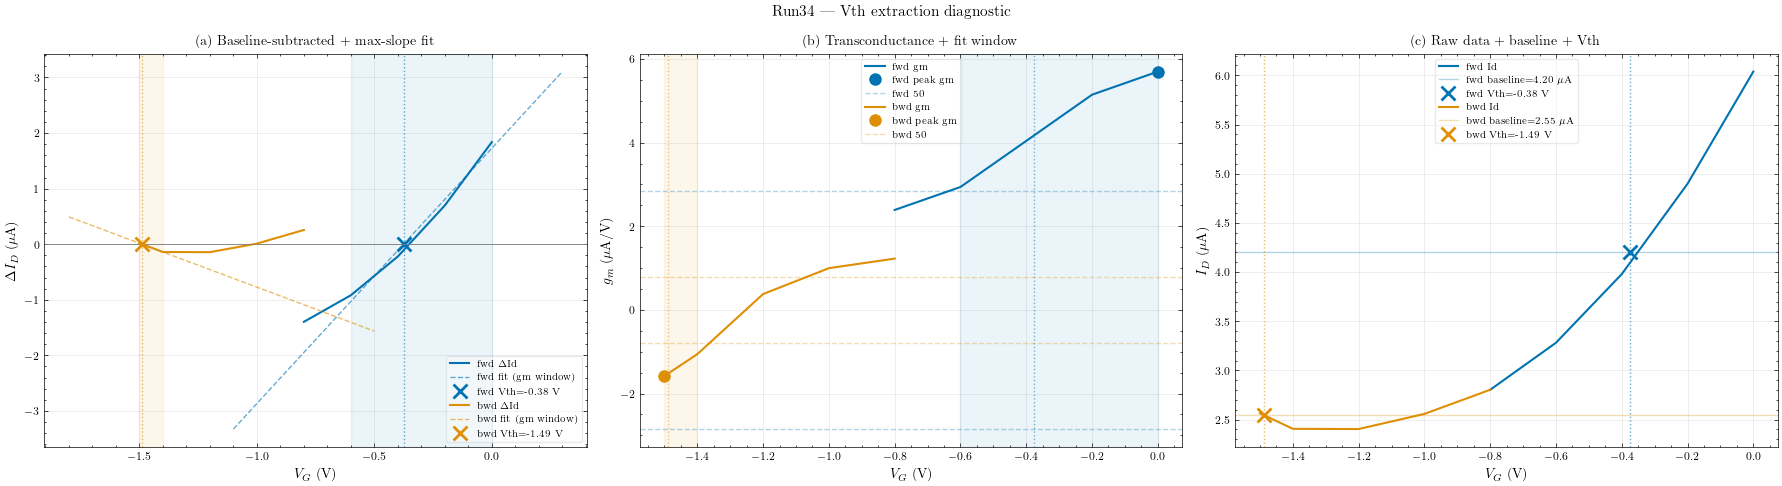

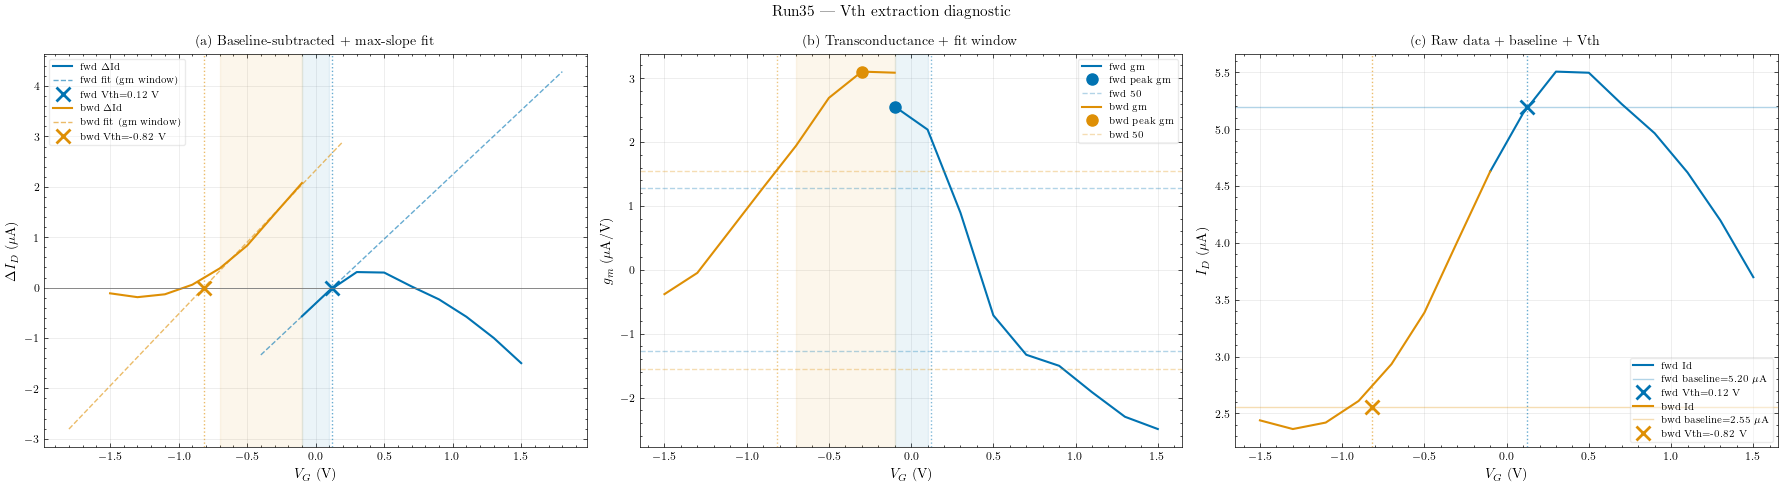

In [ ]:
from importlib import reload
import SMU_functions; reload(SMU_functions)
from SMU_functions import debug_Vth_extraction

# Pick a couple of runs to inspect (adjust as needed)
debug_Vth_extraction([smu_DR009], run_nums=[34, 35], smooth_gm=3)

In [ ]:
## Extract hysteresis from ALL runs to see inter-cycle evolution
hyst_runs = [34, 35, 36, 37, 38, 39, 40, 41]  # all runs; or select a subset

hyst_data = extract_hysteresis([smu_DR009], run_nums=hyst_runs, smooth_gm=3)

# Display extracted parameters
df_hyst = pd.DataFrame(hyst_data)
print(f"Extracted hysteresis data for {len(hyst_data)} sweeps\n")
print(df_hyst[['run_label', 'V_th_fwd', 'V_th_bwd', 'delta_V_th',
               'SS_fwd', 'SS_bwd', 'Q_gate']].to_string(index=False))
df_hyst

Extracted hysteresis data for 8 sweeps

run_label  V_th_fwd  V_th_bwd  delta_V_th       SS_fwd       SS_bwd       Q_gate
    Run34 -0.376002 -1.489134   -1.113132  2201.552580 18100.199769 1.375749e-11
    Run35  0.122986 -0.815920   -0.938906 44238.293614  2986.394864 2.307225e-11
    Run36  0.197251 -0.717162   -0.914413 17041.750895   122.134805 1.752487e-11
    Run37  0.213594 -0.699649   -0.913243  3040.678794  2282.616028 1.825722e-11
    Run38  0.223780 -0.685075   -0.908855  2785.769445  2155.174092 1.834717e-11
    Run39 -0.630736 -0.560096    0.070641  1768.339918  4038.878592 5.942755e-13
    Run40 -0.614008 -0.558305    0.055703  1815.276890  4284.806980 6.041383e-13
    Run41 -0.602883 -0.558305    0.044579  1792.562262  4435.952163 5.197337e-13


,run_label,run_num,gm_max_fwd,V_th_fwd,baseline_fwd,SS_fwd,on_off_fwd,gm_max_bwd,V_th_bwd,baseline_bwd,SS_bwd,on_off_bwd,delta_V_th,Q_gate,I_G_max
0,Run34,34,0.000006,-0.376002,0.000004,2201.552580,2.153473,0.000002,-1.489134,0.000003,18100.199769,1.165974,-1.113132,1.375749e-11,2.623462e-11
1,Run35,35,0.000003,0.122986,0.000005,44238.293614,1.488792,0.000003,-0.815920,0.000003,2986.394864,1.958421,-0.938906,2.307225e-11,2.624835e-11
2,Run36,36,0.000004,0.197251,0.000006,17041.750895,1.297808,0.000004,-0.717162,0.000003,122.134805,2.113218,-0.914413,1.752487e-11,2.653816e-11
3,Run37,37,0.000004,0.213594,0.000006,3040.678794,1.363774,0.000005,-0.699649,0.000003,2282.616028,2.176183,-0.913243,1.825722e-11,2.596337e-11
4,Run38,38,0.000005,0.223780,0.000007,2785.769445,1.446098,0.000005,-0.685075,0.000003,2155.174092,2.228413,-0.908855,1.834717e-11,2.581162e-11
5,Run39,39,0.000006,-0.630736,0.000002,1768.339918,4.843580,0.000001,-0.560096,0.000002,4038.878592,1.350042,0.070641,5.942755e-13,2.415634e-13
6,Run40,40,0.000005,-0.614008,0.000002,1815.276890,4.377153,0.000001,-0.558305,0.000002,4284.806980,1.321282,0.055703,6.041383e-13,2.211665e-13
7,Run41,41,0.000005,-0.602883,0.000002,1792.562262,4.461914,0.000001,-0.558305,0.000002,4435.952163,1.310163,0.044579,5.197337e-13,2.071262e-13


## Step 2: Hysteresis Evolution Across Sweeps

Four-panel diagnostic:

- **(a) $V_{\text{th}}$ forward and backward** — does $V_{\text{th}}$ drift monotonically (trapping/diffusion) or stay stable (ferroelectric)?
- **(b) $\Delta V_{\text{th}}$ (hysteresis window)** — does it grow, saturate, or remain constant?
- **(c) SS forward and backward** — if SS degrades, interface trap creation is occurring (not just rigid band shift).
- **(d) Cumulative gate charge** — provides the $Q_G$ data for the correlation test in Step 4.

In [ ]:
## Hysteresis evolution — 4-panel diagnostic

fig_hyst_evo, _ = plot_hysteresis_evolution([smu_DR009], run_nums=hyst_runs,
                                            smooth_gm=11,
                                            fig_format=fig_format,
                                            export_data=export_data,
                                            output_SMU=output_SMU,
                                            plot_transparency=plot_transparency)

KeyboardInterrupt: 

## Step 3: Model Fitting — Trapping vs Diffusion vs Linear Degradation

Three competing models are fitted to both the inter-cycle $V_{\text{th}}$ shift and the intra-cycle $|\Delta V_{\text{th}}|$ evolution. The independent variable $n$ is the **sweep index** (0, 1, 2, …), not clock time.

1. **Stretched exponential** (charge trapping): $\Delta V(n) = \Delta V_\infty \left(1 - e^{-(n/\tau)^\beta}\right)$
   - $\Delta V_\infty$: saturation shift (V) — the total $V_{\text{th}}$ shift once all available traps are filled.
   - $\tau$: characteristic trapping scale in **sweep cycles** (not seconds). $\tau = 3$ means half the traps fill within ~3 gate-voltage sweeps.
   - $\beta < 1$: broad distribution of trap time-constants (dispersive transport, many trap levels — typical of interface/bulk oxide traps)
   - $\beta = 1$: simple exponential (single dominant defect species, one characteristic time-constant)
   - $\beta > 1$: narrow distribution — trapping is dominated by a single well-defined energy level; the transition sharpens with increasing $\beta$ (Weibull-like). $\beta = 2$ gives Gaussian-like onset.
   - Saturating behaviour is the hallmark of trap filling

2. **Power-law** (diffusion/drift): $\Delta V(n) = A \cdot n^\alpha$
   - $\alpha \approx 0.5$: Fickian diffusion (e.g. oxygen-vacancy redistribution)
   - $\alpha \approx 1.0$: field-driven ionic drift (approaches linear in practice)

3. **Linear** (constant-rate degradation): $\Delta V(n) = a \cdot n + b$
   - Steady defect creation or irreversible electrochemical reaction

**AIC** (Akaike Information Criterion) selects the best model — lower is better, penalising extra parameters.

**Note on intra-cycle scatter:** The $|\Delta V_{\text{th}}|$ panel may appear noisier than the 4-panel hysteresis window because it is the *difference* of two independently extracted $V_{\text{th}}$ values (fwd and bwd), which amplifies extraction noise. The individual $V_{\text{th}}$ trends are typically smoother.

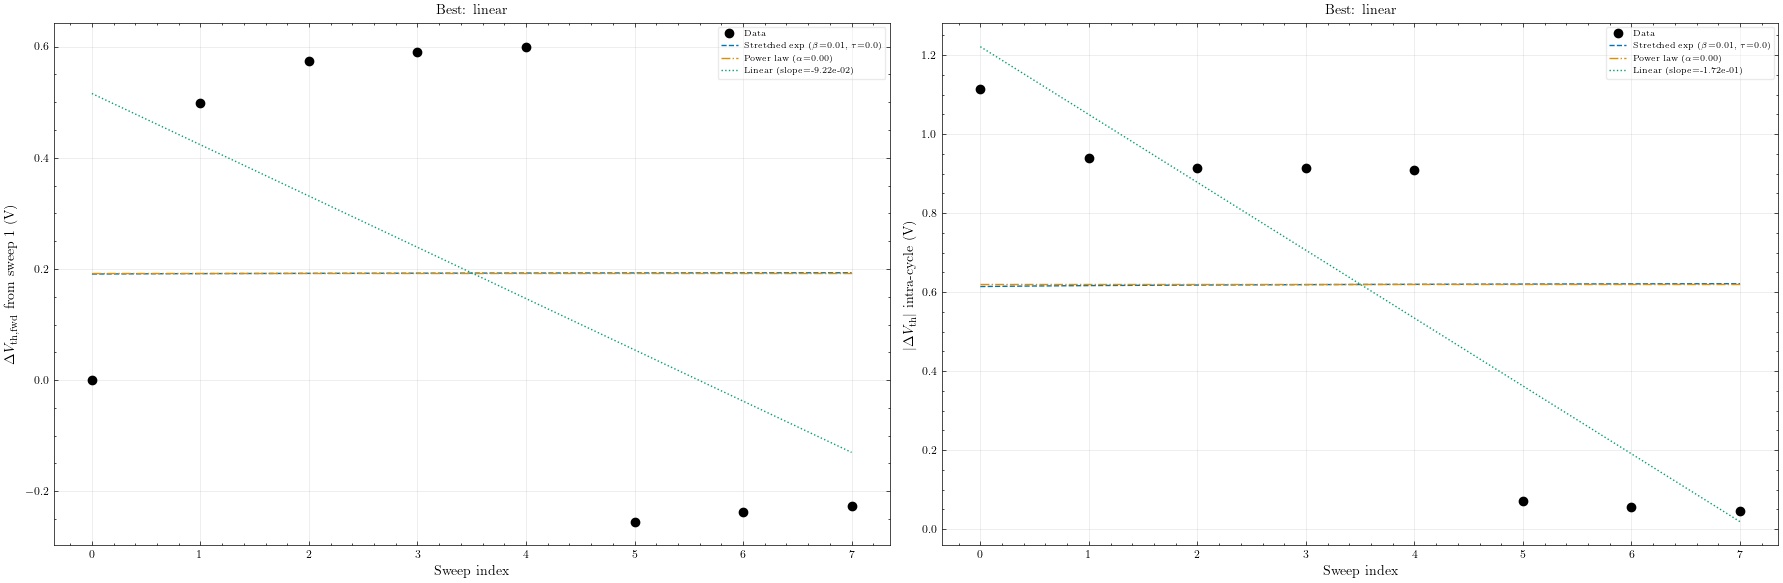


=== Vth_shift ===
  Best model: linear
  stretched_exp         AIC=-9.4  |  dV_inf=0.294, tau=0.01, beta=0.01
  power_law             AIC=-11.4  |  A=0.1927, alpha=6.272e-21
  linear                AIC=-14.4  |  a=-0.09223, b=0.5155

=== abs_dVth ===
  Best model: linear
  stretched_exp         AIC=-7.1  |  dV_inf=0.946, tau=0.01, beta=0.01
  power_law             AIC=-9.1  |  A=0.6199, alpha=1.423e-21
  linear                AIC=-21.9  |  a=-0.1718, b=1.221


In [ ]:
## Fit trapping / diffusion / linear models to V_th drift and |ΔV_th|

fig_fits, fit_stats = fit_hysteresis_model(hyst_data,
                                           fig_format=fig_format,
                                           export_data=export_data,
                                           output_SMU=output_SMU,
                                           plot_transparency=plot_transparency,
                                           #beta_limit=(0, 1),
                                           )

# Print model comparison
for key in ['Vth_shift', 'abs_dVth']:
    print(f"\n=== {key} ===")
    print(f"  Best model: {fit_stats[key]['best_model']}")
    for model, info in fit_stats[key]['fits'].items():
        param_str = ', '.join(f'{n}={v:.4g}' for n, v in zip(info['names'], info['params']))
        print(f"  {model:20s}  AIC={info['AIC']:.1f}  |  {param_str}")

## Step 4: Gate Charge Correlation — Electrochemical Test

If hysteresis is driven by ionic migration (oxygen vacancies, protons), the threshold-voltage shift should scale with the total charge injected through the gate dielectric. We test this by plotting $|\Delta V_{\text{th}}|$ vs cumulative $Q_G = \sum \int |I_G| \, d|V_G|$ and fitting a line.

- **Strong linear correlation** ($R^2 \to 1$): electrochemical / ion-migration mechanism (ECRAM-like)
- **Weak or no correlation**: interface-trap or bulk-trap mechanism (charge trapping dominates over ionic effects)

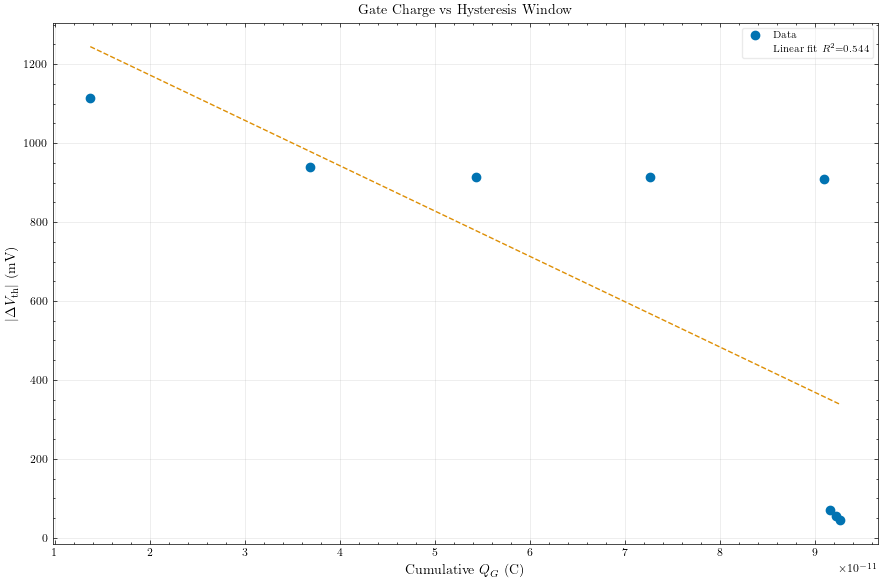

In [ ]:
## Gate charge correlation — electrochemical mechanism test

fig_Qg = plot_charge_correlation(hyst_data,
                                 fig_format=fig_format,
                                 export_data=export_data,
                                 output_SMU=output_SMU,
                                 plot_transparency=plot_transparency)

## Step 5: Interpretation Summary

Read the diagnostics together:

| Observation | → Supports |
|------------|-----------|
| $\Delta V_{\text{th}} > 0$ (clockwise, $V_{\text{th}}^{\text{bwd}} > V_{\text{th}}^{\text{fwd}}$) | Electron trapping during forward sweep |
| $\Delta V_{\text{th}} < 0$ (counter-clockwise) | Hole trapping, or mobile positive ions (O vacancies) drifting under gate field |
| $V_{\text{th}}$ drift **saturates** (stretched exp. wins, $\beta < 1$) | Distributed trap filling — classic charge trapping |
| $V_{\text{th}}$ drift follows **power-law** ($\alpha \approx 0.5$) | Fickian diffusion of mobile species |
| $V_{\text{th}}$ drift is **linear** | Constant-rate defect creation or steady ionic drift |
| SS **degrades** across sweeps | Interface trap generation (not just bulk shift) |
| SS **stable** but $V_{\text{th}}$ shifts | Rigid band shift: bulk oxide charge or mobile ions |
| Strong $Q_G$ correlation ($R^2 > 0.8$) | Electrochemical / ion-migration mechanism |
| Weak $Q_G$ correlation ($R^2 < 0.3$) | Charge trapping (not ionic) |